# Lecture 8 — Class Exercise
## Choropleth Maps

> **Push to:** `week08/lecture08_exercise.ipynb`

**Rules:**
1. Use `px.choropleth` or `px.choropleth_map` — choose deliberately and state your reason
2. Right colour scale for your data (sequential vs diverging) — state which and why
3. Insight title names a geographic finding — not just a topic
4. `featureidkey` must be correctly matched to your GeoJSON

---


In [1]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import json


## Task 1 — World choropleth: life expectancy diverging scale

**What to build:** A world choropleth showing **life expectancy relative to the global average** using a diverging colour scale.

**Requirements:**
- Use the Gapminder dataset for 2007: `px.data.gapminder()`
- Compute each country's deviation from the global mean life expectancy
- Diverging scale centred at zero (= world average)
- `hover_data` showing country name, raw life expectancy, and deviation
- Insight title naming which region is furthest below average

> 💡 `gm_2007['lifeExp'].mean()` gives you the global average to subtract from


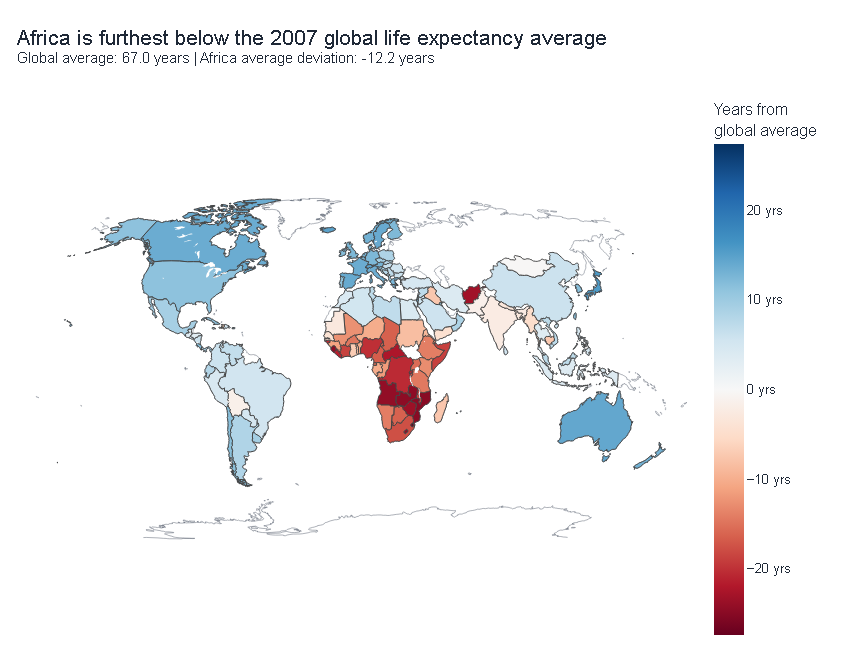

In [2]:
# Task 1 - World choropleth: life expectancy relative to global average

gm = px.data.gapminder()
gm_2007 = gm.loc[gm["year"] == 2007].copy()

global_avg_life = gm_2007["lifeExp"].mean()
gm_2007["lifeExp_deviation"] = gm_2007["lifeExp"] - global_avg_life

continent_summary = (
    gm_2007
    .groupby("continent", as_index=False)["lifeExp_deviation"]
    .mean()
    .sort_values("lifeExp_deviation")
)

lowest_continent = continent_summary.iloc[0]

fig = px.choropleth(
    gm_2007,
    locations="iso_alpha",
    color="lifeExp_deviation",
    hover_name="country",
    hover_data={
        "continent": True,
        "lifeExp": ":.1f",
        "lifeExp_deviation": ":.1f",
        "iso_alpha": False
    },
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0,
    projection="natural earth",
    labels={
        "lifeExp_deviation": "Life expectancy vs global average",
        "lifeExp": "Life expectancy"
    },
    title=(
        f"Africa is furthest below the 2007 global life expectancy average"
        f"<br><sup>Global average: {global_avg_life:.1f} years | "
        f"{lowest_continent['continent']} average deviation: {lowest_continent['lifeExp_deviation']:.1f} years</sup>"
    )
)

fig.update_layout(
    template="plotly_white",
    height=650,
    width=1000,
    title=dict(x=0.02, xanchor="left", font=dict(size=21)),
    font=dict(family="Arial", size=13, color="#1F2937"),
    margin=dict(l=20, r=20, t=90, b=20),
    coloraxis_colorbar=dict(
        title="Years from<br>global average",
        ticksuffix=" yrs"
    )
)

fig.update_geos(
    showframe=False,
    showcoastlines=True,
    coastlinecolor="rgba(75, 85, 99, 0.45)",
    showcountries=True,
    countrycolor="white"
)

fig.show()


## Task 2 — Find your own GeoJSON

**What to build:** A choropleth using a GeoJSON file you find yourself online.

**Requirements:**
- Find a free GeoJSON file for any geography that interests you (country, region, city)
- Create or find a matching dataset with at least one numeric variable per region
- Build either a `px.choropleth` or `px.choropleth_mapbox` — state your choice and reason in the markdown cell below
- Correctly identify and set `featureidkey` by inspecting the GeoJSON properties
- Choose sequential or diverging scale — state your reason in the markdown cell below
- Insight title naming a geographic finding

**Where to find GeoJSON files:**
- [geojson.xyz](https://geojson.xyz/) — countries, cities, natural features
- [naturalearthdata.com](https://www.naturalearthdata.com/) — global admin boundaries
- [github.com/datasets/geo-countries](https://github.com/datasets/geo-countries) — country polygons
- Search: `[country name] [admin level] GeoJSON github` — most countries have free boundary files on GitHub

> 💡 Before plotting, always inspect your GeoJSON properties first:
> ```python
> print(my_geojson['features'][0]['properties'])
> ```
> The property name that matches your dataframe's location column is what goes in `featureidkey='properties.???'`


### Task 2 — Design decisions

**GeoJSON source:**  
Natural Earth country boundaries from geojson.xyz:  
https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_0_countries.geojson

**Chart type chosen** (`px.choropleth` or `px.choropleth_mapbox`) **and reason:**  
I used `px.choropleth` because the data is country-level data and the goal is to compare values across countries on a world map. A standard choropleth is clearer here than `px.choropleth_mapbox` because street-level map detail is not needed.

**Colour scale chosen** (sequential or diverging) **and reason:**  
I used a sequential colour scale because `CO2_per_capita` is a magnitude variable. The values increase from low to high, so a light-to-dark sequential scale clearly shows which countries have higher emissions per person.

In [3]:
# Task 2 - Custom GeoJSON choropleth: CO2 per capita by country

from urllib.request import urlopen

geojson_url = "https://d2ad6b4ur7yvpq.cloudfront.net/naturalearth-3.3.0/ne_110m_admin_0_countries.geojson"

with urlopen(geojson_url) as response:
    world_geojson = json.load(response)

print("Example GeoJSON properties:")
print(world_geojson["features"][0]["properties"])

custom_df = pd.read_csv("../data/gapminder.csv").copy()

# Match local country names to the Natural Earth GeoJSON country-name field.
country_name_fix = {
    "USA": "United States of America",
    "UK": "United Kingdom",
    "Russia": "Russia",
    "South Korea": "South Korea",
    "DR Congo": "Democratic Republic of the Congo"
}

custom_df["geo_country"] = custom_df["Country"].replace(country_name_fix)

top_co2 = custom_df.loc[custom_df["CO2_per_capita"].idxmax()]

fig = px.choropleth(
    custom_df,
    geojson=world_geojson,
    locations="geo_country",
    featureidkey="properties.name",
    color="CO2_per_capita",
    hover_name="Country",
    hover_data={
        "Continent": True,
        "GDP_per_capita": ":,.0f",
        "Life_expectancy": ":.1f",
        "Population": ":,.0f",
        "CO2_per_capita": ":.1f",
        "geo_country": False
    },
    color_continuous_scale="YlOrRd",
    projection="natural earth",
    labels={
        "CO2_per_capita": "CO2 per capita",
        "GDP_per_capita": "GDP per capita",
        "Life_expectancy": "Life expectancy"
    },
    title=(
        f"Saudi Arabia has the highest CO2 per capita in the selected country dataset"
        f"<br><sup>{top_co2['Country']}: {top_co2['CO2_per_capita']:.1f} tonnes per person</sup>"
    )
)

fig.update_layout(
    template="plotly_white",
    height=650,
    width=1000,
    title=dict(x=0.02, xanchor="left", font=dict(size=21)),
    font=dict(family="Arial", size=13, color="#1F2937"),
    margin=dict(l=20, r=20, t=90, b=20),
    coloraxis_colorbar=dict(
        title="CO2 per<br>capita"
    )
)

fig.update_geos(
    fitbounds="locations",
    visible=False,
    showframe=False,
    showcoastlines=True,
    coastlinecolor="rgba(75, 85, 99, 0.45)",
    showcountries=True,
    countrycolor="white"
)

fig.show()

Example GeoJSON properties:
{'scalerank': 1, 'labelrank': 3, 'sovereignt': 'Afghanistan', 'sov_a3': 'AFG', 'adm0_dif': 0, 'level': 2, 'type': 'Sovereign country', 'admin': 'Afghanistan', 'adm0_a3': 'AFG', 'geou_dif': 0, 'geounit': 'Afghanistan', 'gu_a3': 'AFG', 'su_dif': 0, 'subunit': 'Afghanistan', 'su_a3': 'AFG', 'brk_diff': 0, 'name': 'Afghanistan', 'name_long': 'Afghanistan', 'brk_a3': 'AFG', 'brk_name': 'Afghanistan', 'brk_group': None, 'abbrev': 'Afg.', 'postal': 'AF', 'formal_en': 'Islamic State of Afghanistan', 'formal_fr': None, 'note_adm0': None, 'note_brk': None, 'name_sort': 'Afghanistan', 'name_alt': None, 'mapcolor7': 5, 'mapcolor8': 6, 'mapcolor9': 8, 'mapcolor13': 7, 'pop_est': 28400000, 'gdp_md_est': 22270, 'pop_year': -99, 'lastcensus': 1979, 'gdp_year': -99, 'economy': '7. Least developed region', 'income_grp': '5. Low income', 'wikipedia': -99, 'fips_10': None, 'iso_a2': 'AF', 'iso_a3': 'AFG', 'iso_n3': '004', 'un_a3': '004', 'wb_a2': 'AF', 'wb_a3': 'AFG', 'woe_id':